In [22]:
!pip install opencv-python



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


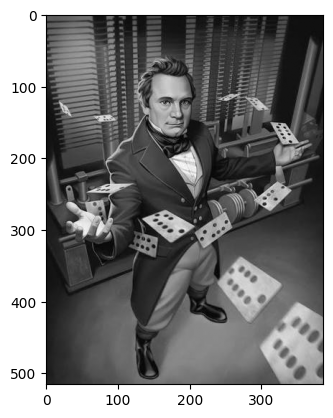

In [6]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

img  = cv2.imread(r"C:\Users\venki\Downloads\image.jpg",0).astype(np.float32)

plt.imshow(img,cmap="gray",vmin=0,vmax=255)
plt.show()

In [7]:
a = np.log(1+np.max(img))
a

np.float32(5.5451775)

In [9]:
255/a

np.float32(45.985905)

In [10]:
np.log(img+1)

array([[4.543295 , 4.543295 , 4.543295 , ..., 2.8332133, 2.8332133,
        2.944439 ],
       [4.543295 , 4.543295 , 4.543295 , ..., 2.8332133, 2.8332133,
        2.944439 ],
       [4.543295 , 4.543295 , 4.543295 , ..., 2.8332133, 2.8332133,
        2.944439 ],
       ...,
       [3.610918 , 3.610918 , 3.610918 , ..., 5.030438 , 4.9904327,
        4.9698133],
       [3.610918 , 3.610918 , 3.610918 , ..., 5.0106354, 4.962845 ,
        4.934474 ],
       [3.610918 , 3.610918 , 3.610918 , ..., 4.9972124, 4.94876  ,
        4.919981 ]], shape=(516, 387), dtype=float32)

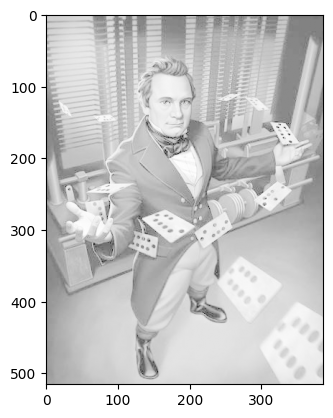

In [11]:
c = 255 / np.log(1+np.max(img))
log_out = c * (np.log(img+1))

plt.imshow(log_out,cmap="gray")
plt.show()

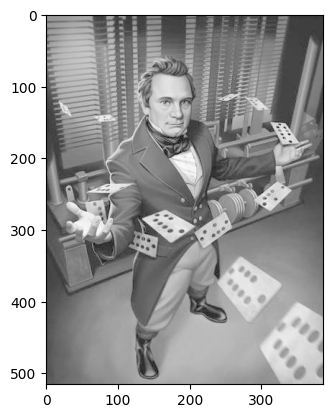

In [12]:
gamma = 0.5
gamma_out = np.array(255*(img/255)**gamma,dtype="uint8")

plt.imshow(gamma_out,cmap="gray")
plt.show()

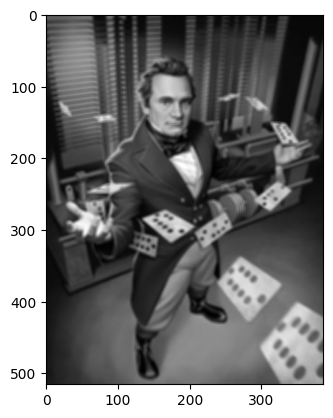

In [13]:
kernel = np.ones((5,5))/25
blur_out = cv2.filter2D(img,-1,kernel)

plt.imshow(blur_out,cmap="gray")
plt.show()

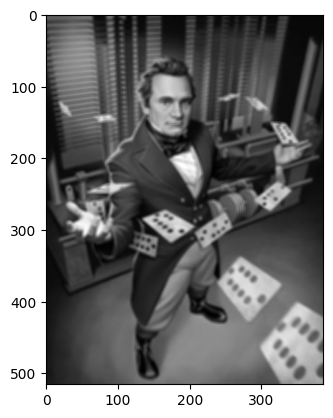

In [14]:
kernel = np . ones ((5 ,5) ) / 25
blur_out = cv2 . filter2D ( img , -1 , kernel )
plt.imshow(blur_out,cmap='grey')

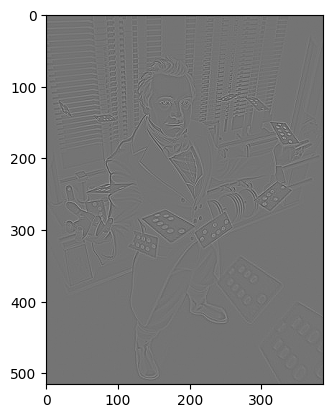

In [15]:
lap_kernel = np . array ([[0 , 1 , 0] , [1 , -4 , 1] , [0 , 1 , 0]])
laplacian = cv2 . filter2D ( img , -1 , lap_kernel )

plt.imshow(laplacian,cmap ='grey')

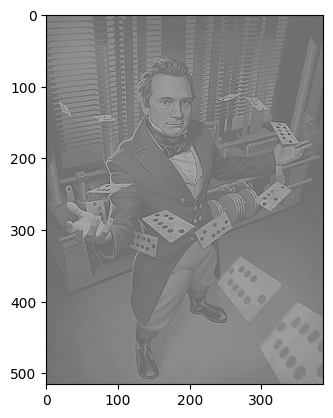

In [16]:
sharpened = img.astype(np.float32)-laplacian
plt.imshow(sharpened, cmap ='grey')

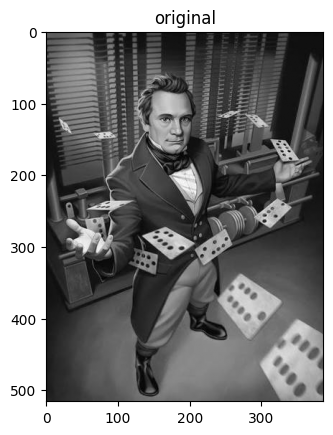

In [17]:
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
# Display
plt.title('original')
plt.imshow(img, cmap ='grey')

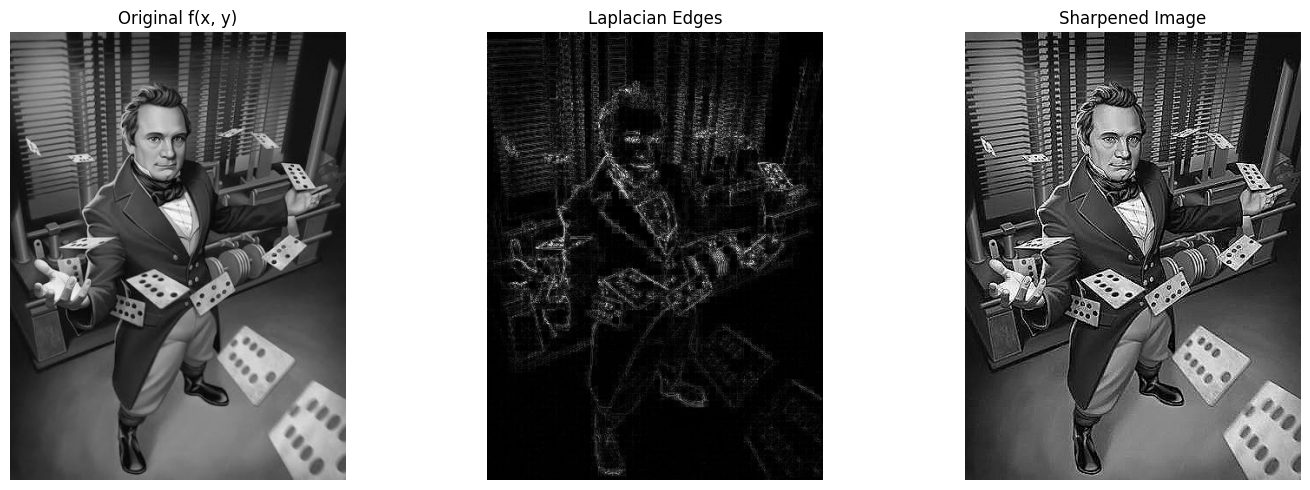

In [18]:
plt.figure(figsize=(15, 5)) # Made slightly wider to fit 3 images comfortably

# 1. First image on the far left
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original f(x, y)")
plt.axis('off')

# 2. Second image in the middle
plt.subplot(1, 3, 2)
plt.imshow(cv2.convertScaleAbs(laplacian), cmap='gray')
plt.title('Laplacian Edges')
plt.axis('off')

# 3. Third image on the far right
plt.subplot(1, 3, 3)
plt.imshow(sharpened, cmap='gray', vmin=0, vmax=255)
plt.title('Sharpened Image')
plt.axis('off')

plt.tight_layout()
plt.show()


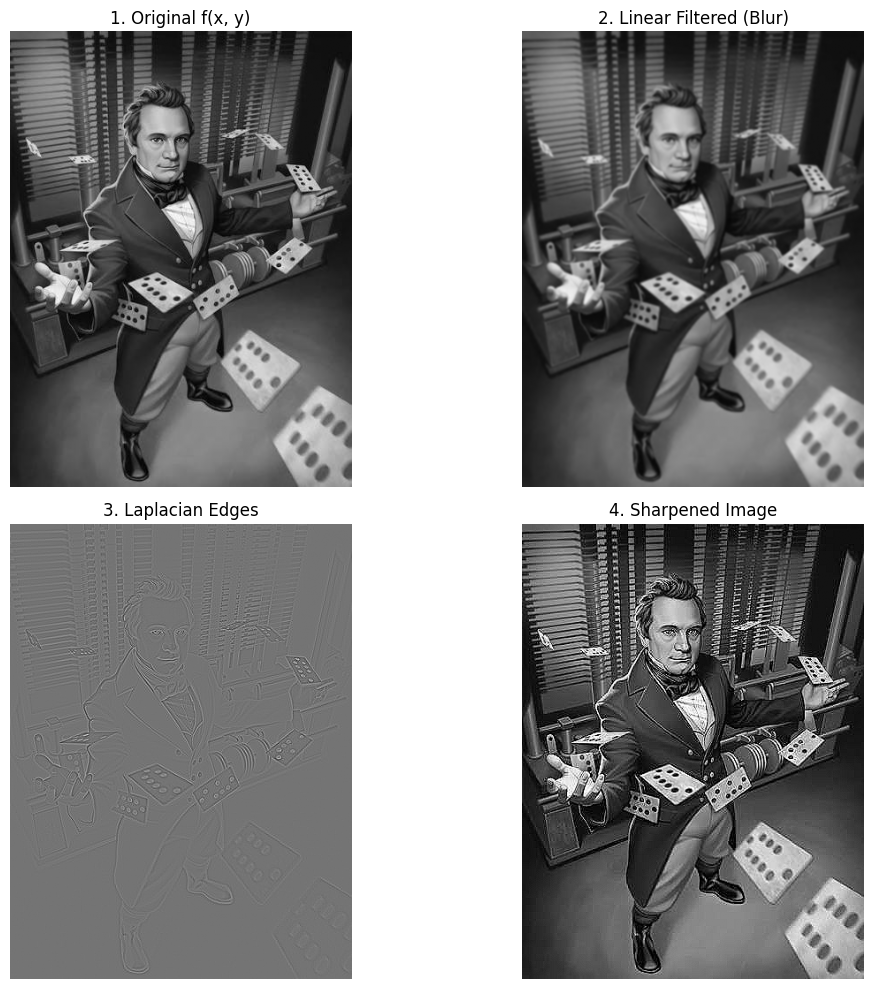

In [19]:
blurred = cv2.GaussianBlur(img, (5, 5), 0)

plt.figure(figsize=(12, 10))

# Top Left: Original Image
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("1. Original f(x, y)")
plt.axis('off')

# Top Right: Blurred Image (New addition)
plt.subplot(2, 2, 2)
plt.imshow(blurred, cmap='gray', vmin=0, vmax=255)
plt.title("2. Linear Filtered (Blur)")
plt.axis('off')

# Bottom Left: Laplacian Edges
plt.subplot(2, 2, 3)
plt.imshow(laplacian, cmap='gray')
plt.title('3. Laplacian Edges')
plt.axis('off')

# Bottom Right: Sharpened Image
plt.subplot(2, 2, 4)
plt.imshow(sharpened, cmap='gray', vmin=0, vmax=255)
plt.title('4. Sharpened Image')
plt.axis('off')

plt.tight_layout()
plt.show()
